In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_cleaned.csv")
df.head()

,Order_ID,Order_Date,Ship_Date,Customer_ID,Customer_Name,Segment,Country,City,Region,Category,...,Order_Year,Quarter,Is_Loss_Order,Discount_Category,High_Value_Order,Duplicate_Check,Negative Profit Orders,High Discount Orders (>30%),Delivery_Days.1,Unnamed: 30
0,ORD00001,2022-01-09,2022-01-15,CUST1403,Andrew White,Corporate,USA,Los Angeles,Central,Furniture,...,2022,1,Yes,Medium,No,False,2076.0,622.0,6,6.0
1,ORD00002,2022-07-24,2022-07-26,CUST1406,Pamela Grant,Corporate,UK,Birmingham,England,Furniture,...,2022,3,Yes,Medium,Yes,NaN,NaN,NaN,2,NaN
2,ORD00003,2023-09-27,2023-10-01,CUST1365,Billy Davis,Home Office,India,Bangalore,North,Furniture,...,2023,3,No,Low,Yes,NaN,NaN,NaN,4,NaN
3,ORD00004,2023-11-16,2023-11-22,CUST1074,Kelsey Stephens,Home Office,UK,Liverpool,England,Furniture,...,2023,4,Yes,Medium,No,NaN,NaN,NaN,6,NaN
4,ORD00005,2023-05-14,2023-05-21,CUST1173,Katherine Vega,Corporate,USA,Houston,East,Office Supplies,...,2023,2,No,Low,Yes,NaN,NaN,NaN,7,NaN


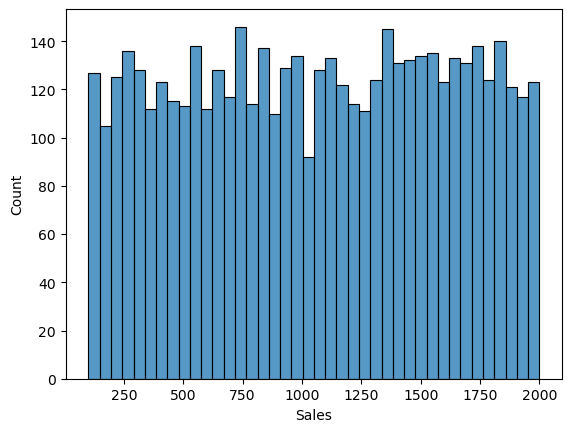

In [6]:
#Sales Distribution

sns.histplot(df["Sales"], bins=40)
plt.show()

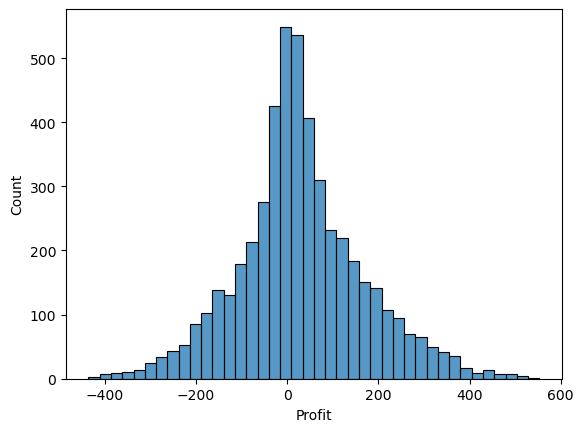

In [8]:
#Profit Distribution

sns.histplot(df["Profit"], bins=40)
plt.show()

In [17]:
#RFM Analysis

import pandas as pd

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

snapshot = df["Order_Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer_Name").agg({
    "Order_Date": lambda x: (snapshot - x.max()).days,
    "Order_ID": "count",
    "Sales": "sum"
})

rfm.columns = ["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer_Name,,,
Adam Jones,41,6,6512.28
Alec Burgess,7,7,7587.13
Alex Graham,212,13,12786.60
Alex Sims,40,11,13515.90
Alexander Ross,58,8,8254.70


In [15]:
#Regression

from sklearn.linear_model import LinearRegression

X = df[["Discount"]]
y = df["Profit"]

model = LinearRegression()
model.fit(X,y)

LinearRegression()

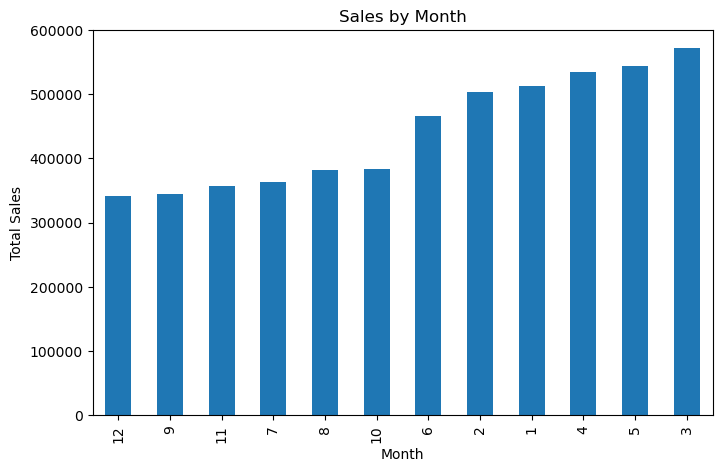

In [22]:
# Which months generate the highest sales?
monthly_sales = df.groupby("Order_Month")["Sales"].sum().sort_values()

monthly_sales.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()


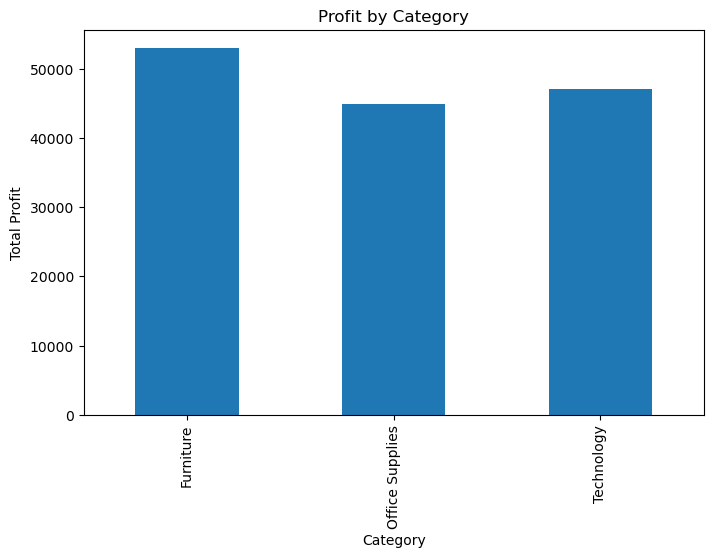

In [23]:
# Which product categories generate the most profit?

category_profit = df.groupby("Category")["Profit"].sum()

category_profit.plot(kind="bar", figsize=(8,5))

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

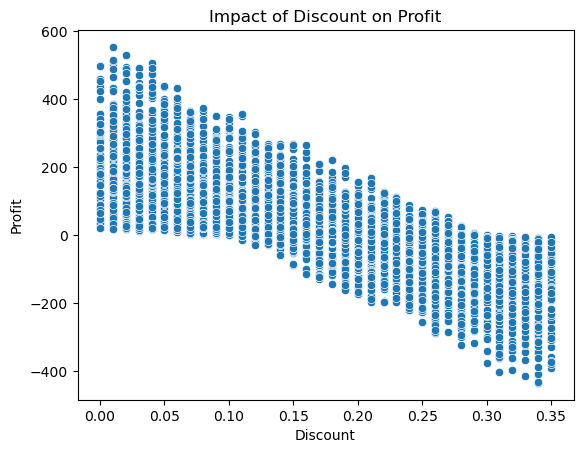

In [24]:
# Does discount affect profit?

sns.scatterplot(x="Discount", y="Profit", data=df)

plt.title("Impact of Discount on Profit")

plt.show()

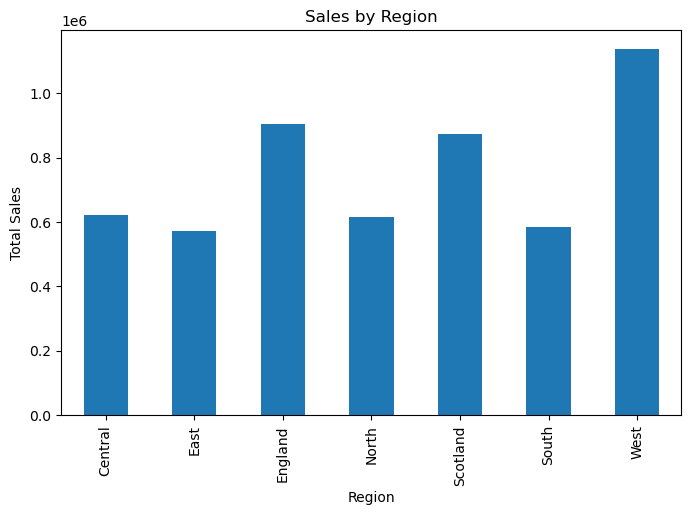

In [25]:
# Which regions generate the most sales?

region_sales = df.groupby("Region")["Sales"].sum()

region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

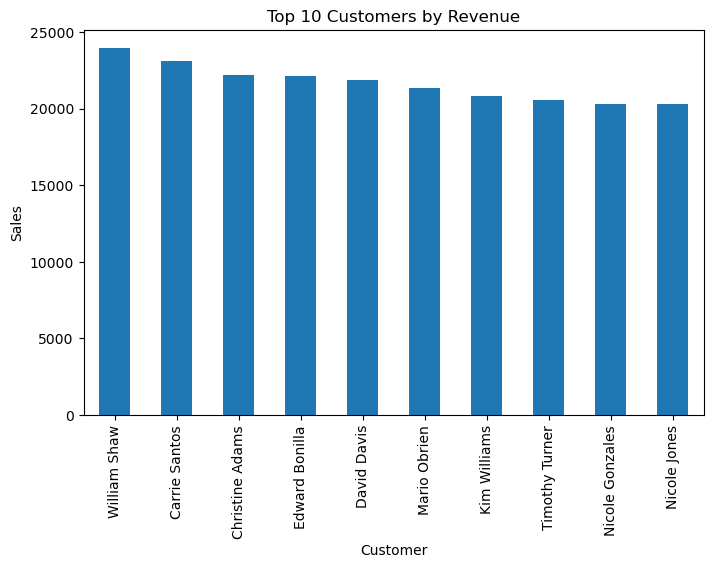

In [26]:
# Who are the top 10 customers by revenue?

top_customers = df.groupby("Customer_Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_customers.plot(kind="bar", figsize=(8,5))

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer")
plt.ylabel("Sales")

plt.show()

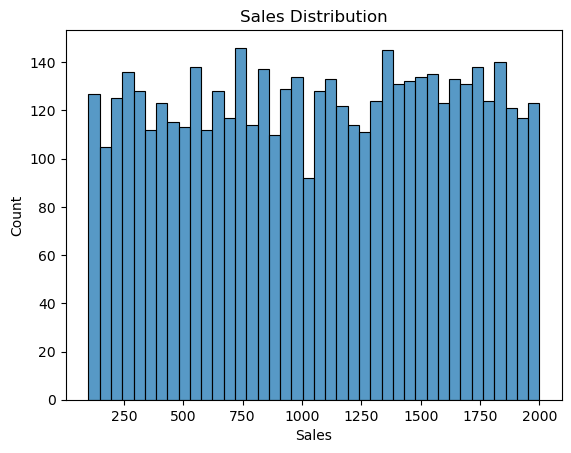

In [27]:
# What is the distribution of sales values?

sns.histplot(df["Sales"], bins=40)

plt.title("Sales Distribution")

plt.show()